In [1]:
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as plt
import sklearn.datasets as dt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve
import pickle
from sklearn.ensemble import RandomForestClassifier
import scipy.spatial.distance as spd
import sklearn.preprocessing as pp
from sklearn.decomposition import PCA
import numpy.linalg as la
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
respostas_file = './A51597_Ficha3_Respostas.p'
with open(respostas_file, 'rb') as f:
    respostas = pickle.load(f)
    
respostas.keys()

dict_keys(['Q001', 'nome', 'numero'])

In [3]:
fs = '../data/MNISTsmall.p'
with open(fs, 'rb') as f:
    DATASET = pickle.load(f)
    
DATASET.keys()

dict_keys(['data', 'target', 'DESCR', 'target_names', 'foldTrain'])

In [4]:
from tkinter import Y


X = DATASET['data']
y = DATASET['target']
foldTrain = DATASET['foldTrain']

X_test = X[:, foldTrain]
y_test = y[foldTrain]

print(X_test.shape)
print(y_test.shape)
print(np.unique(y))

(784, 10000)
(10000,)
[0 1 2 3 4 5 6 7 8 9]


In [5]:
zeros = X_test.T[y_test == 0]
print(zeros.shape)

X1 = zeros[:337]

(1000, 784)


In [6]:
print(X1.shape)
pca = PCA()
pca.fit(X1)

X1_pca = pca.transform(X1)
print(X1_pca.shape)

cs = np.cumsum(np.var(X1_pca, axis=0))/np.sum(np.var(X1_pca, axis=0))

min_comp = np.where(cs >= 0.43)[0][0] + 1
print(min_comp)

# erro absoluto
reconstruido = pca.inverse_transform(X1_pca[min_comp])
erro = np.abs(X1 - reconstruido)
print(np.round(np.mean(erro), 0))

respostas['Q001'][0] = [0, 0, 0, 1]

(337, 784)
(337, 337)
4
41.0


In [7]:
X1_235 = X1[235]
pca = PCA(n_components=4)
X1_pca_50 = pca.fit_transform(X1)
reconstruido_50 = pca.inverse_transform(X1_pca_50)
erro_50 = np.abs(X1 - reconstruido_50)
print(np.round(np.mean(erro_50), 0))

24.0


In [8]:
X_test_0= X_test[:, y_test == 0]
X_test_0= X_test_0[:, :337]

Cx_0= np.cov(X_test_0)
u_0, W_0= np.linalg.eig(Cx_0)
u_0= np.real(u_0)      
W_0= np.real(W_0) 

Xproj= np.dot(W_0.T, X_test_0)

var= np.var(Xproj, axis= 1)
var_n= var/ np.sum(var)
var_cum= np.cumsum(var_n)

n_comp= np.sum(var_cum < 0.43) 

idx_0= np.argsort(-(u_0))   
u_0= u_0[idx_0]              
W_0= W_0[:, idx_0]     

digito= X_test_0[:, 234]
comp_princ= W_0[:, :n_comp]
digito_proj= np.dot(comp_princ.T, digito)
digito_rec= np.dot(comp_princ, digito_proj)

print(np.mean(np.abs(digito - digito_rec)))

34.368749059389394


In [9]:
print("Exercício 1 c)")
digit_213 = X1.T[:, 234]

C0 = np.cov(X1.T)
eigenvalues, eigenvectors = la.eig(C0)

eigenvalues_sorted = np.sort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues_sorted[eigenvalues_sorted > 1e-10]

var_por = eigenvalues_sorted / np.sum(eigenvalues_sorted)
var_cumsum = np.cumsum(var_por)

n_components = np.sum(var_cumsum < 0.43) + 1

idx = np.argsort(-eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

W = eigenvectors[:, :n_components]
proj = np.dot(W.T, digit_213)
reconstructed = np.dot(W, proj)

mae = np.mean(np.abs(digit_213 - reconstructed))
print(f"Erro absoluto médio: {mae:.0f}")

Exercício 1 c)
Erro absoluto médio: 29
Erro absoluto médio: 29


In [10]:
C0 = np.cov(X1.T)
print(C0.shape)

respostas['Q001'][1] = [1, 0, 0, 0]

(784, 784)


In [11]:
# Norma do vetor de media dos dados
mu0 = np.mean(X1.T, axis=0)
norm_mu0 = la.norm(mu0)
print(norm_mu0)

843.7114192823803


In [12]:
# O desvio padrão da dimensão 195 dos dados
d = np.std(X1, axis=0)
print(d[195])

respostas['Q001'][2] = [0, 1, 0, 0]

0.0


In [13]:
cs = np.cumsum(np.var(X1_pca, axis=0))/np.sum(np.var(X1_pca, axis=0))

np.where(cs >= 0.9)[0][0] + 1

respostas['Q001'][3] = [0, 0, 1, 0]

In [14]:
# Numero de valores próprios superiores a 10^-10 da matriz de covariância dos dados
eigenvalues, eigenvectors = la.eig(C0)
num_eigenvalues = np.sum(eigenvalues > 1e-10)
print(num_eigenvalues)

respostas['Q001'][4] = [0, 0, 0, 1]

336


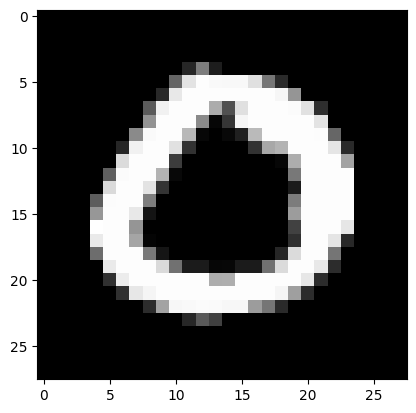

In [15]:
plt.imshow(X1[204].reshape(28, 28), cmap='gray')

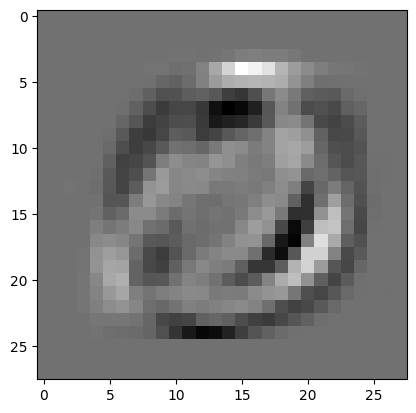

In [16]:
# 13º vetor proprioriedade
aux = eigenvectors[:, eigenvalues>1e-10]
aux = np.real(aux)

plt.imshow(np.real(aux[:, 12]).reshape(28, 28), cmap='gray')

In [17]:
respostas['Q001'][5] = [0, 0, 0, 1]

In [18]:
print(respostas['Q001'])

[[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


In [19]:
pickle.dump(respostas, open('./A51597_Ficha3_Respostas_2.p', 'wb'))

In [20]:
with open('./A51597_Ficha3_Respostas_2.p', 'rb') as f:
    respostas_check = pickle.load(f)
    
print(respostas_check['Q001'])

[[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]
